# Question 01

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load runway image in grayscale
f = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found. Check the path.'
print('Image shape:', f.shape)
print('Image dtype:', f.dtype)

Image shape: (769, 765)
Image dtype: uint8


### (a) Gamma correction with γ = 0.5.

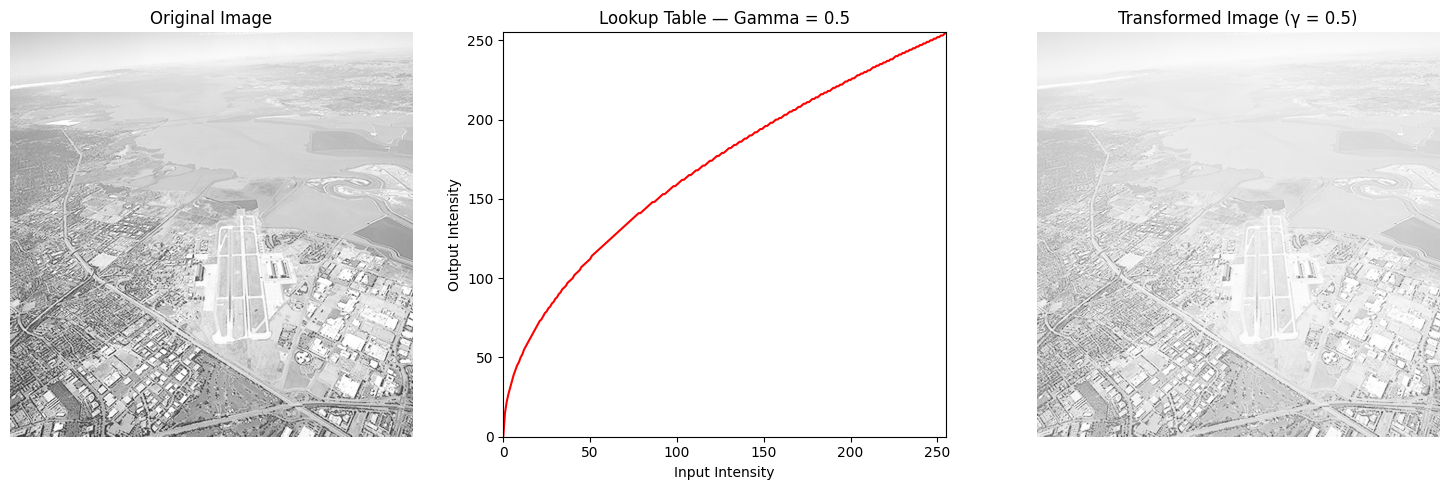

In [ ]:
gamma = 0.5

t = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

g_gamma5 = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title('Lookup Table — Gamma = 0.5')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_gamma5, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Image (γ = 0.5)')
ax[0].axis('off')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Transformed image brighter than original image. The LUT curve bends upward, meaning dark pixel values are mapped to much higher output values.

### (b) Gamma correction with γ = 2.

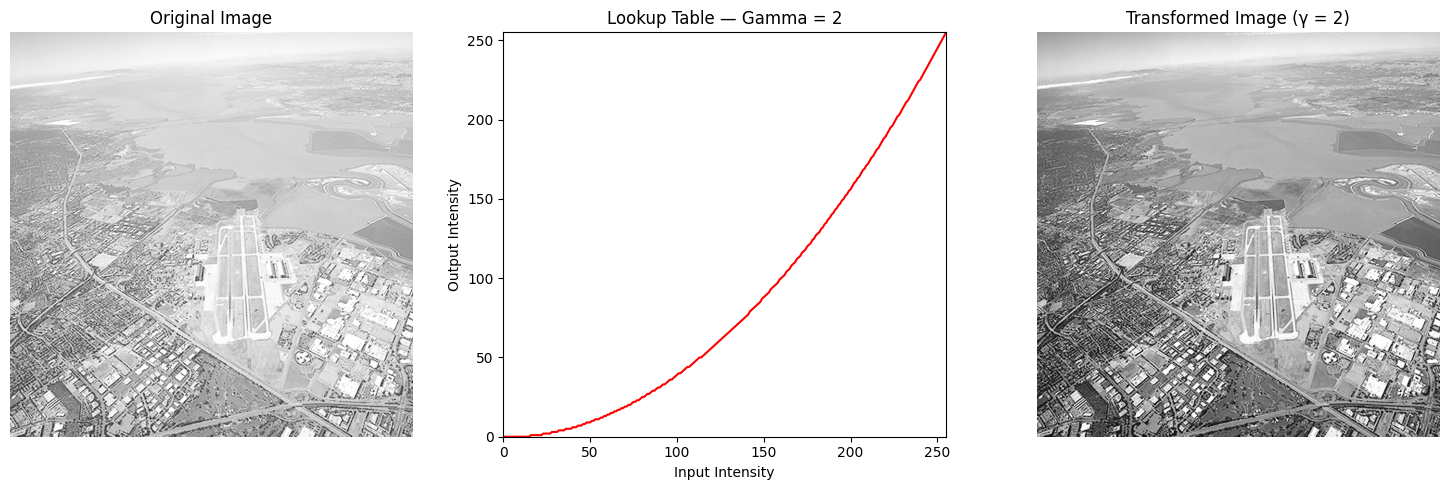

In [7]:
gamma = 2

t = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

g_gamma2 = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title('Lookup Table — Gamma = 2')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_gamma2, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Image (γ = 2)')
ax[2].axis('off')
plt.tight_layout()
plt.show()

Transformed image darker than original image. The LUT curve bends downward, compressing mid-tone and bright pixel values toward lower intensities.

### (c) Contrast Stretching (linear piecewise transformation)

LUT length: 256


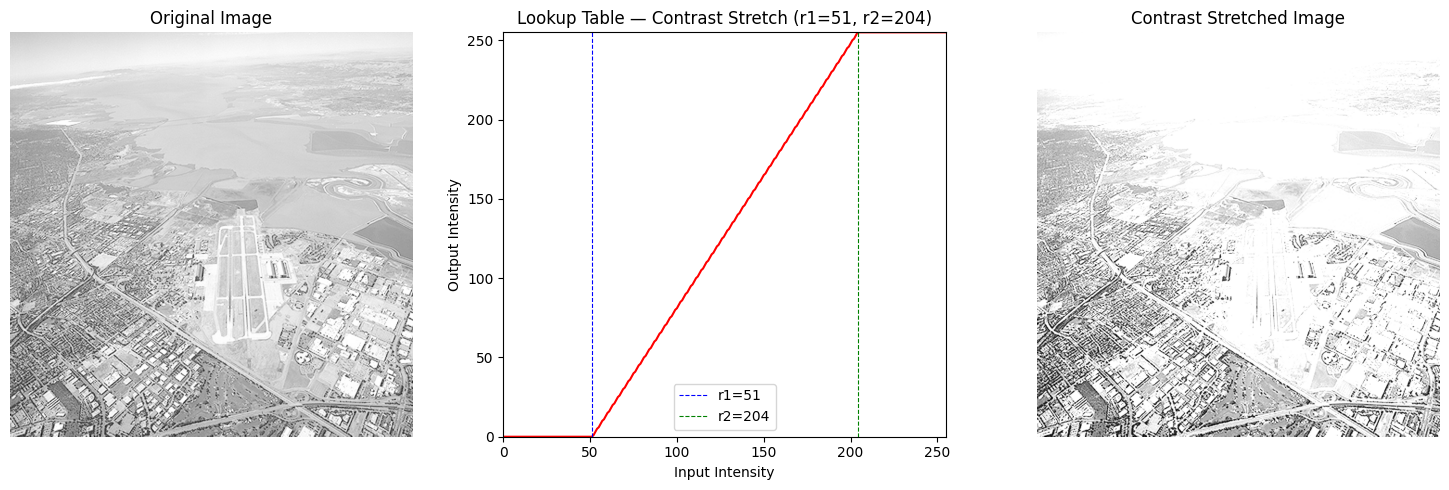

In [8]:
# Convert normalized r1, r2 to 0-255 pixel range
r1 = int(0.2 * 255)  # 51
r2 = int(0.8 * 255)  # 204

# Build LUT in 3 segments
t1 = np.zeros(r1, dtype=np.uint8)                        # 0.......50  --> 0
t2 = np.linspace(0, 255, r2 - r1 + 1).astype(np.uint8)  # 51.......204 --> 0.......255
t3 = np.full(255 - r2, 255, dtype=np.uint8)              # 205.......255 --> 255

t = np.concatenate((t1, t2, t3))
print('LUT length:', len(t))  # 256

g_contrast = t[f]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].plot(np.arange(256), t, color='red')
ax[1].set_title(f'Lookup Table — Contrast Stretch (r1={r1}, r2={r2})')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].axvline(x=r1, color='blue', linestyle='--', linewidth=0.8, label=f'r1={r1}')
ax[1].axvline(x=r2, color='green', linestyle='--', linewidth=0.8, label=f'r2={r2}')
ax[1].legend()
ax[1].set_xlim(0, 255)
ax[1].set_ylim(0, 255)
ax[2].imshow(g_contrast, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Contrast Stretched Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()

Pixels below intensity 51 are clipped to 0 (pure black) and pixels above 204 are clipped to 255 (pure white). The middle range [51, 204] is linearly stretched across the full [0, 255] range. This maximizes contrast in the mid-tones of the runway image, making features within that intensity range more visible , but it reduces detail in the very dark and very bright areas.